<a href="https://colab.research.google.com/github/enzobanin/AnaliseDeDados/blob/main/sonoEstiloDeVida.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Sono e Estilo de Vida
##Dicionário


*    Person ID: Identificador do indivíduo
*    Gender: Gênero (Masculino/Feminino).
*   Age: Idade em anos.
*  Occupation: Profissão.
*   Sleep Duration (hours): Horas de sono por dia.
*   Quality of Sleep (scale: 1-10): Qualidade do sono (escala de 1 a 10)
*   Physical Activity Level (minutes/day): Atividade física diária (minutos).
*    Stress Level (scale: 1-10): Nível de estresse (escala de 1 a 10).
*  BMI Category: Categoria de IMC.
*   Blood Pressure (systolic/diastolic): Pressão arterial (sistólica/diastólica).
*   Heart Rate (bpm): Frequência cardíaca (bpm)
*   Daily Steps: Passos por dia.
*  Sleep Disorder: Distúrbio do sono (Nenhum, Insônia, Apneia do Sono).



##Descrição geral:
Base Fictícia composta por dados sobre hábitos de sono, saúde e estilo de vida de 400 indivíduos. Pode ser
usada para explorar a relação entre qualidade de vida e distúrbios do sono.

##Desafios de análise:
*   Investigar fatores que afetam a qualidade e duração do sono.
*   Relacionar estresse e atividade física com distúrbios.
*   Analisar indicadores de saúde cardiovascular





In [1]:
from google.colab import drive
drive.mount('/content/drive')
#path = "/content/drive/MyDrive/5 semestre/sonoEstiloDeVida/02_sono_estilo_vida.csv"
path = "/content/drive/MyDrive/Colab Notebooks/sonoEstiloDeVida/02_sono_estilo_vida.csv"

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(path, sep=',')
df.head(5)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [5]:
pd.set_option("display.float_format", "{:.2f}".format)
df.describe()
#Verificamos um alto desvio padrão em 'Daily Steps'

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.00,374.00,374.00,374.00,374.00,374.00,374.00,374.00
mean,187.50,42.18,7.13,7.31,59.17,5.39,70.17,6816.84
std,108.11,8.67,0.80,1.20,20.83,1.77,4.14,1617.92
min,1.00,27.00,5.80,4.00,30.00,3.00,65.00,3000.00
25%,94.25,35.25,6.40,6.00,45.00,4.00,68.00,5600.00
50%,187.50,43.00,7.20,7.00,60.00,5.00,70.00,7000.00
75%,280.75,50.00,7.80,8.00,75.00,7.00,72.00,8000.00
max,374.00,59.00,8.50,9.00,90.00,8.00,86.00,10000.00


A variável 'Daily Steps' apresenta um desvio padrão de aproximadamente 1617 passos, o que representa uma variação significativa em relação à média de 6816 passos diários. Isso demonstra que há uma grande diversidade no nível de atividade física entre os indivíduos da amostra, com alguns apresentando comportamento mais sedentário e outros com níveis mais elevados de movimentação diária.

array([[<Axes: title={'center': 'Person ID'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Sleep Duration'}>],
       [<Axes: title={'center': 'Quality of Sleep'}>,
        <Axes: title={'center': 'Physical Activity Level'}>,
        <Axes: title={'center': 'Stress Level'}>],
       [<Axes: title={'center': 'Heart Rate'}>,
        <Axes: title={'center': 'Daily Steps'}>, <Axes: >]], dtype=object)

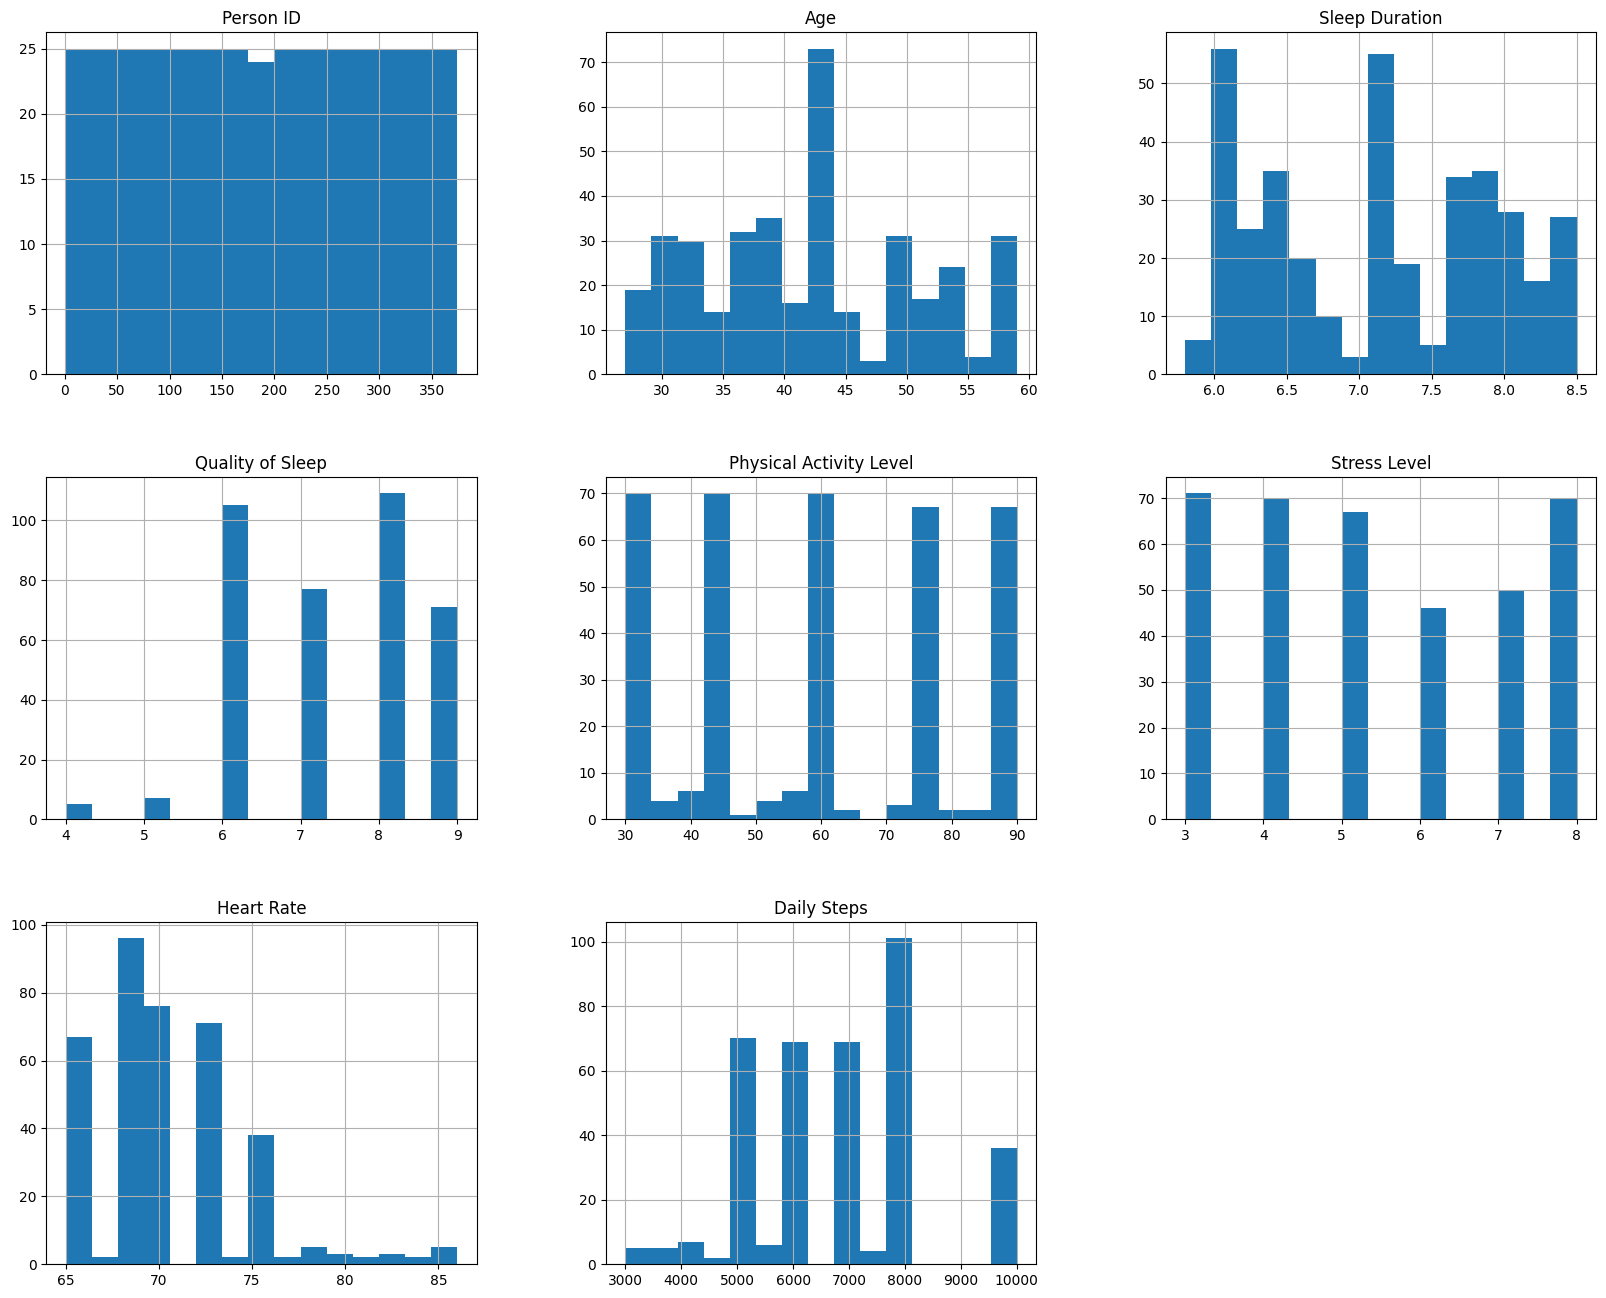

In [6]:
df.hist(bins=15, figsize=(20,16))

Ao analisarmos os histogramas, observamos que os indivíduos da amostra são predominantemente adultos de meia idade com padrão de sono entre 6.5h e 8.5h, porém com qualidade polarizada entre boa e ruim. Identificamos que o nível de estresse se concentra nos extremos baixo e alto, reforçando sua relevância para investigar a relação com o sono. Por fim, verificamos grande variação nos passos diários, indicando diversidade no nível de atividade física entre os participantes.

In [7]:
df.duplicated().sum()
#verifica os duplicados

np.int64(0)

Verificamos que em nossa amostra não possuímos nenhuma linha/coluna repetida. Simplificando nossa análise.

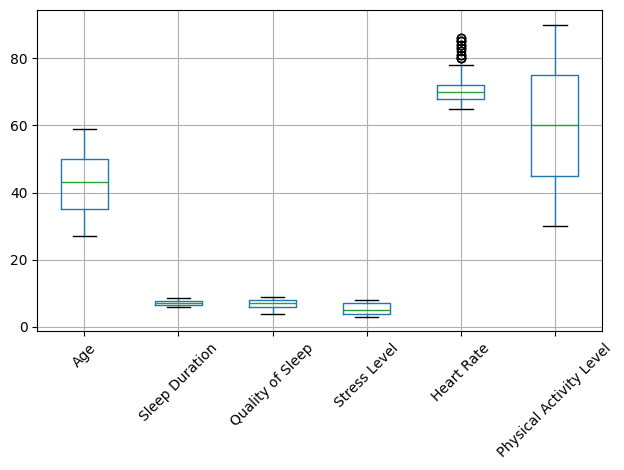

In [8]:
df[['Age', 'Sleep Duration', 'Quality of Sleep', 'Stress Level', 'Heart Rate', 'Physical Activity Level']].boxplot()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ao analisarmos o boxplot, verificamos que Age e Physical Activity Level apresentam maior dispersão entre as variáveis, com caixas mais amplas indicando maior variabilidade na amostra. Sleep Duration, Quality of Sleep e Stress Level possuem distribuições compactas e simétricas, sugerindo dados consistentes e homogêneos. O Heart Rate se destaca por ser a única variável com outliers acima de 80 bpm, indicando que alguns indivíduos apresentam frequência cardíaca significativamente elevada em relação à maioria da amostra.

<Axes: >

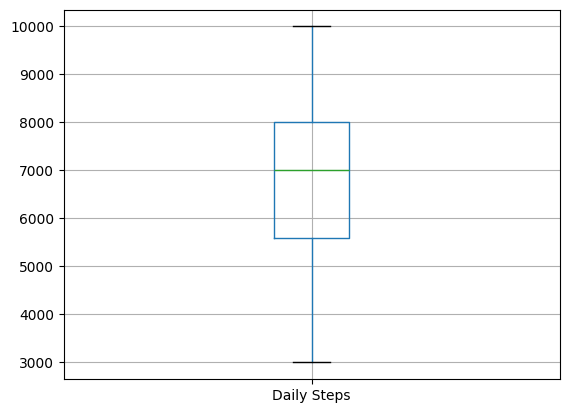

In [9]:
df[['Daily Steps']].boxplot()

Ao analisar o boxplot do Daily Steps, notamos que a maioria das pessoas caminha entre 5.600 e 8.000 passos por dia, com uma mediana próxima de 7.000 passos. Não foram identificados outliers, mas chama atenção a amplitude entre o mínimo de 3.000 e o máximo de 10.000 passos, o que mostra que há pessoas bem sedentárias e outras bastante ativas dentro da amostra.

In [10]:
#Verificando se há valores nulos
((df.isnull().sum() / df.shape[0]) * 100).sort_values(ascending=False)

,0
Sleep Disorder,58.56
Gender,0.00
Age,0.00
Occupation,0.00
Person ID,0.00
Sleep Duration,0.00
Quality of Sleep,0.00
Stress Level,0.00
Physical Activity Level,0.00
BMI Category,0.00


Podemos notar que apenas o atributo 'Sleep Disorder' possui valores faltantes, cerca de 58%. Esses dados são referente a pessoas que não detém nenhum tipo de Sleep Disorder.

In [11]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('No Disorder')

Preenchemos os valores faltantes com 'No Disorder' para uma análise mais precisa e de melhor compreensão.

In [25]:
df[df['Sleep Disorder'].isna()]

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder


Verificamos se todos os dados de 'Sleep Disorder' foram preenchidos.

In [26]:
df_without_disorder = df[df['Sleep Disorder'] == 'No Disorder']
df_without_disorder

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.10,6,42,6,Overweight,126/83,77,4200,No Disorder
1,2,Male,28,Doctor,6.20,6,60,8,Normal,125/80,75,10000,No Disorder
2,3,Male,28,Doctor,6.20,6,60,8,Normal,125/80,75,10000,No Disorder
7,8,Male,29,Doctor,7.80,7,75,6,Normal,120/80,70,8000,No Disorder
8,9,Male,29,Doctor,7.80,7,75,6,Normal,120/80,70,8000,No Disorder
...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,342,Female,56,Doctor,8.20,9,90,3,Normal Weight,118/75,65,10000,No Disorder
342,343,Female,56,Doctor,8.20,9,90,3,Normal Weight,118/75,65,10000,No Disorder
343,344,Female,57,Nurse,8.10,9,75,3,Overweight,140/95,68,7000,No Disorder
358,359,Female,59,Nurse,8.00,9,75,3,Overweight,140/95,68,7000,No Disorder


Nos retorna todos que não possuem 'Sleep Disorder'.

In [14]:
condicao = df[df['Quality of Sleep'] > 7]
condicao

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
32,33,Female,31,Nurse,7.90,8,75,4,Normal Weight,117/76,69,6800,No Disorder
50,51,Male,32,Engineer,7.50,8,45,3,Normal,120/80,70,8000,No Disorder
51,52,Male,32,Engineer,7.50,8,45,3,Normal,120/80,70,8000,No Disorder
66,67,Male,32,Accountant,7.20,8,50,6,Normal Weight,118/76,68,7000,No Disorder
84,85,Male,35,Software Engineer,7.50,8,60,5,Normal Weight,120/80,70,8000,No Disorder
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.10,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.00,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.10,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.10,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [41]:
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')
df['BMI Category'].unique()

array(['Overweight', 'Normal', 'Obese'], dtype=object)

In [43]:
df.groupby(["Stress Level","Sleep Disorder"])["Quality of Sleep"].mean()

Stress Level  Sleep Disorder
3             Insomnia         9.00
              No Disorder      8.95
              Sleep Apnea      9.00
4             Insomnia         7.04
              No Disorder      7.95
              Sleep Apnea      8.67
5             Insomnia         7.67
              No Disorder      7.95
              Sleep Apnea      7.50
6             Insomnia         7.00
              No Disorder      7.00
              Sleep Apnea      7.00
7             Insomnia         6.07
              No Disorder      6.00
              Sleep Apnea      5.50
8             Insomnia         5.33
              No Disorder      6.00
              Sleep Apnea      5.76
Name: Quality of Sleep, dtype: float64

In [35]:
df.groupby("Stress Level")[["Quality of Sleep", "Physical Activity Level"]].mean()
#Tentamos comprovar a hipotese de que o Nivel de Atividade Fisica estaria ligado a qualidade do sono

,Quality of Sleep,Physical Activity Level
Stress Level,,
3,8.97,54.72
4,7.67,55.79
5,7.90,74.25
6,7.00,67.15
7,6.00,43.84
8,5.86,58.34


In [42]:
df.groupby(["Stress Level", "BMI Category"])["Quality of Sleep"].mean()
#Notamos que o nivel de estresse influencia mais do que o BMI Category pois
#pessoas Obese se tiverem pouco estresse, dormem melhor comparado com os de muito estresse

Stress Level  BMI Category
3             Normal         8.95
              Obese          9.00
              Overweight     9.00
4             Normal         8.00
              Overweight     7.18
5             Normal         8.00
              Obese          7.00
              Overweight     7.00
6             Normal         7.11
              Overweight     6.50
7             Normal         5.20
              Obese          6.00
              Overweight     6.09
8             Normal         6.00
              Obese          4.00
              Overweight     5.88
Name: Quality of Sleep, dtype: float64

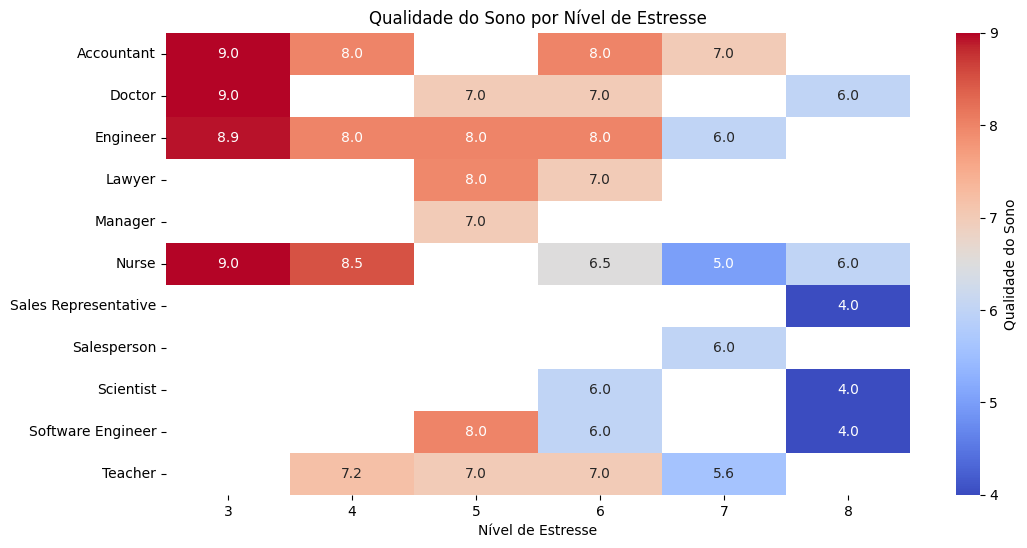

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

resultado_sleep = (
    df.groupby(["Occupation", "Stress Level"])["Quality of Sleep"]
    .mean()
    .unstack()
)

plt.figure(figsize=(12, 6))

ax = sns.heatmap(
    resultado_sleep,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    cbar_kws={"label": "Qualidade do Sono"}
)

plt.title("Qualidade do Sono por Nível de Estresse")
plt.xlabel("Nível de Estresse")
plt.ylabel("")

plt.show()

In [16]:
# IMC x Distúrbio do sono
df.groupby(["BMI Category", "Sleep Disorder"]).size().reset_index(name="count")
#isso responde algo mais direto: pessoas com Overweight têm mais apneia do sono? — o que é um insight muito mais valioso para o relatório!

,BMI Category,Sleep Disorder,count
0,Normal,Insomnia,7
1,Normal,No Disorder,183
2,Normal,Sleep Apnea,5
3,Normal Weight,Insomnia,2
4,Normal Weight,No Disorder,17
5,Normal Weight,Sleep Apnea,2
6,Obese,Insomnia,4
7,Obese,Sleep Apnea,6
8,Overweight,Insomnia,64
9,Overweight,No Disorder,19


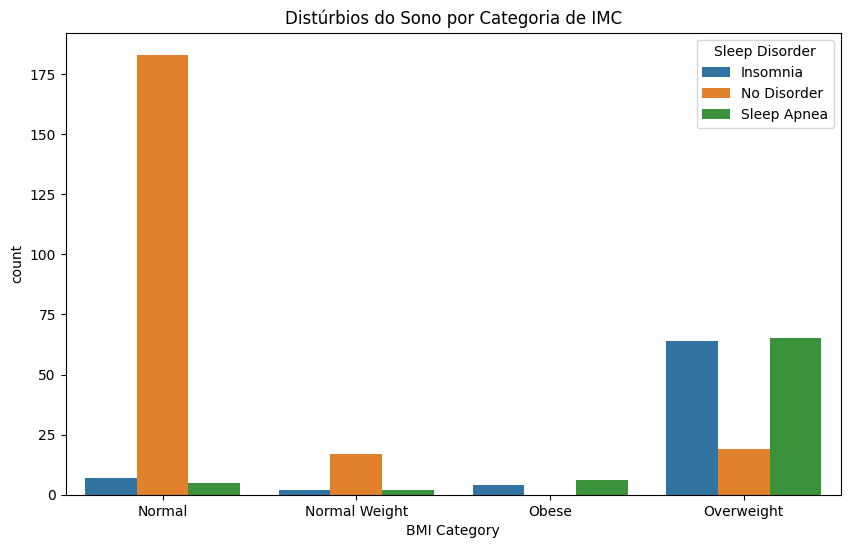

In [17]:
resultado_bmi = df.groupby(["BMI Category", "Sleep Disorder"]).size().reset_index(name="count")
plt.figure(figsize=(10, 6))
sns.barplot(data=resultado_bmi, x="BMI Category", y="count", hue="Sleep Disorder")
plt.title("Distúrbios do Sono por Categoria de IMC")
plt.show()

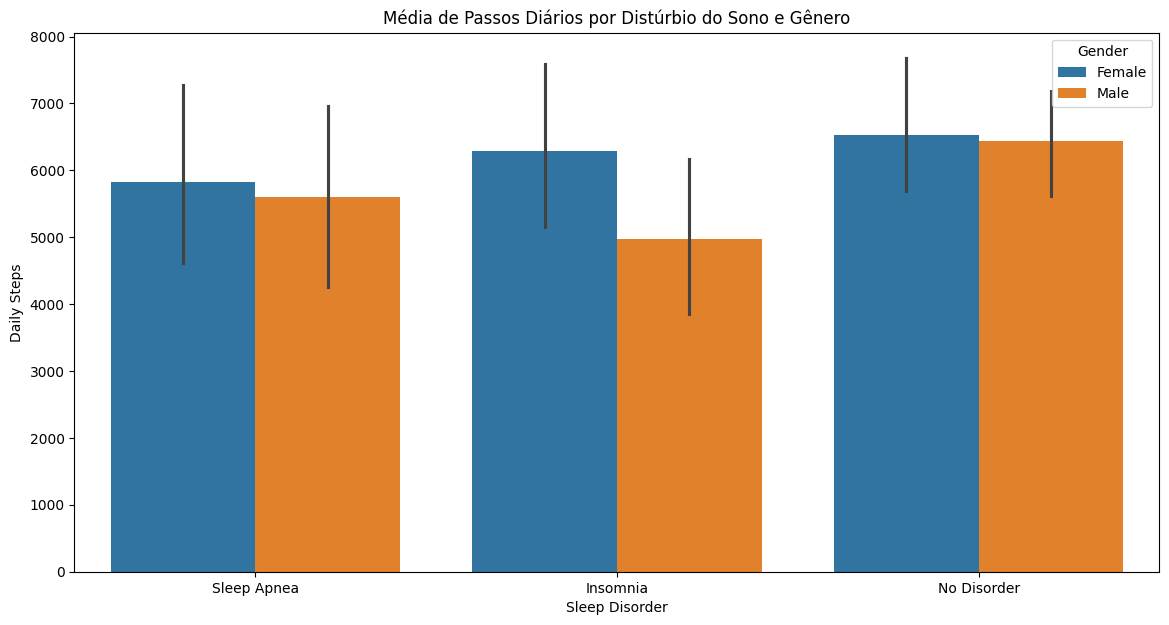

In [18]:
resultado = df.groupby(["Gender", "Quality of Sleep", "Stress Level", "Sleep Disorder"])["Daily Steps"].mean().reset_index().round(0)
# round(0) e reset_index adicionados por Luiz para melhorar a formatação

plt.figure(figsize=(14, 7))
sns.barplot(data=resultado, x="Sleep Disorder", y="Daily Steps", hue="Gender")
plt.title("Média de Passos Diários por Distúrbio do Sono e Gênero")
plt.show()


In [19]:
# Qualidade média do sono por profissão
desafio1_ocupacao = df.groupby("Occupation")["Quality of Sleep"].mean().reset_index().round(1).sort_values("Quality of Sleep", ascending=False)
desafio1_ocupacao

,Occupation,Quality of Sleep
2,Engineer,8.40
0,Accountant,7.90
3,Lawyer,7.90
5,Nurse,7.40
4,Manager,7.00
10,Teacher,7.00
1,Doctor,6.60
9,Software Engineer,6.50
7,Salesperson,6.00
8,Scientist,5.00


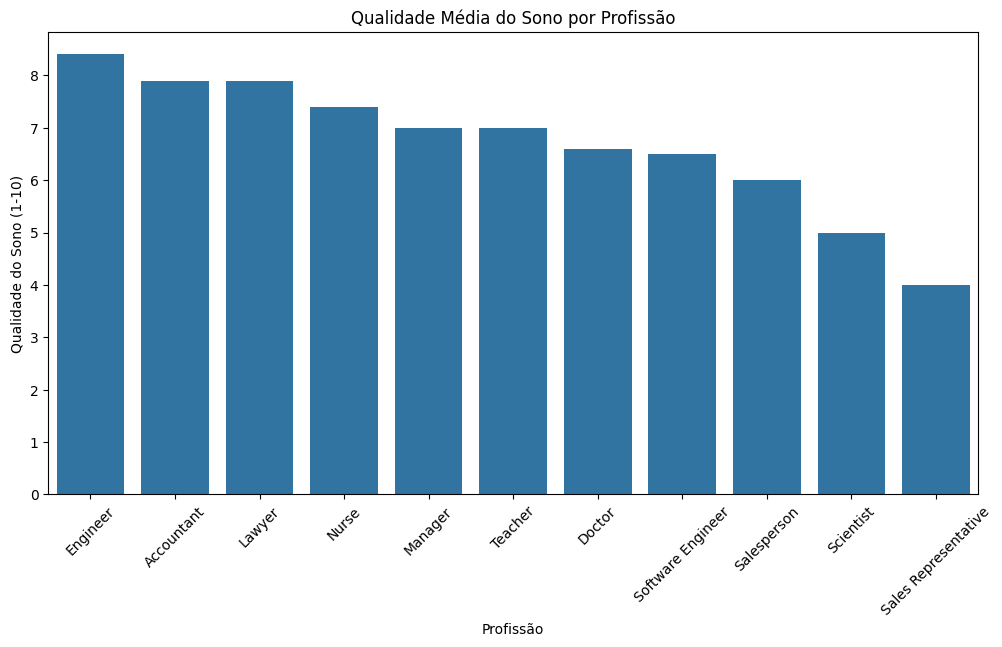

In [20]:

plt.figure(figsize=(12, 6))
sns.barplot(data=desafio1_ocupacao, x="Occupation", y="Quality of Sleep")
plt.title("Qualidade Média do Sono por Profissão")
plt.xlabel("Profissão")
plt.ylabel("Qualidade do Sono (1-10)")
plt.xticks(rotation=45)
plt.show()

In [21]:
desafio1_estresse = df.groupby("Stress Level")["Sleep Duration"].mean().reset_index().round(1)

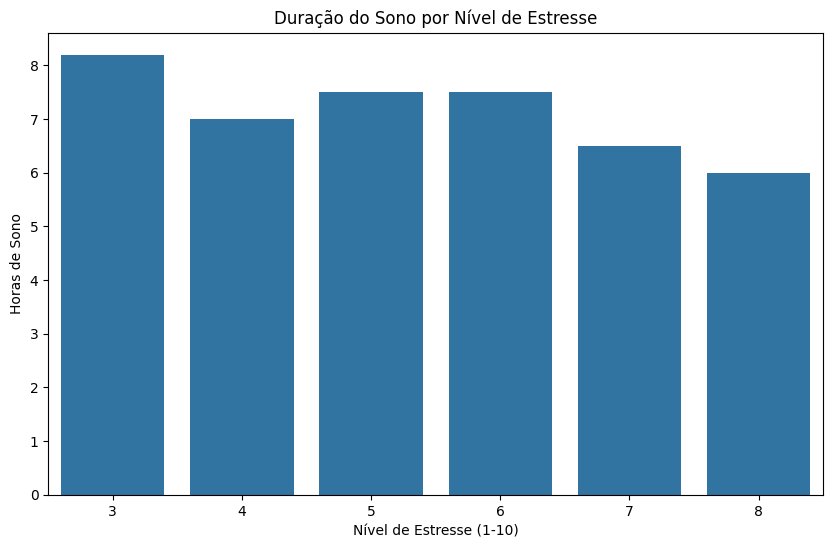

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(data=desafio1_estresse, x="Stress Level", y="Sleep Duration")
plt.title("Duração do Sono por Nível de Estresse")
plt.xlabel("Nível de Estresse (1-10)")
plt.ylabel("Horas de Sono")
plt.show()

In [23]:
# Qualidade do sono por gênero
desafio1_genero = df.groupby("Gender")["Quality of Sleep"].mean().reset_index().round(2)
desafio1_genero

,Gender,Quality of Sleep
0,Female,7.66
1,Male,6.97


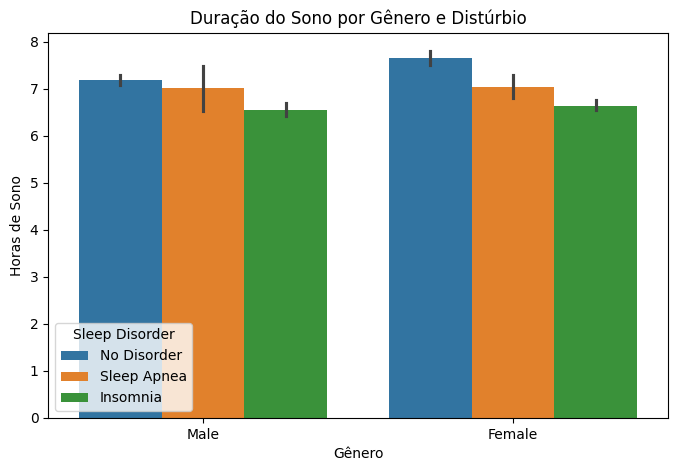

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Gender", y="Sleep Duration", hue="Sleep Disorder")
plt.title("Duração do Sono por Gênero e Distúrbio")
plt.xlabel("Gênero")
plt.ylabel("Horas de Sono")
plt.show()